In [ ]:
import torch
from torch import nn
import pandas as pd
import numpy as np
import gpytorch
from sklearn.preprocessing import MinMaxScaler
from tqdm.notebook import tqdm
import random
import mysql.connector

from Functions import EDFA_Modelling
import CustomKernels.LaplacianKernel as LK
import CustomKernels.LaplacianKernelUncertainty as LKUncertain
import CustomKernels.UncertainKernel as UncertainKernel
import CustomKernels.UncertainMeanConstant as UncertainMean
import CustomKernels.UncertainMeanZero as UncertainZeroMean

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
uncertain = False

### Data Preprocessing

In [2]:
inputPowers = pd.read_csv("data/EDFA 1/Inputs.csv", index_col=0)
outputPowers = pd.read_csv("data/EDFA 1/Outputs.csv", index_col=0)

EDFA_settings = pd.read_csv("data/EDFA 1/EDFA_setting.csv", index_col=0)
config = pd.read_csv("data/EDFA 1/perms.csv", index_col=0)

onChannels = config.copy()
onChannels[onChannels > -1] = 1
onChannels[onChannels == -1] = 0

onChannels = onChannels.to_numpy()


scaledInputs, outputPowersArr, initialVariance = EDFA_Modelling.preprocess_data(inputPowers, outputPowers, EDFA_settings, onChannels, uncertain)

### Splitting Data

In [3]:
numTraining = 300
testIndex = 300

X_train, y_train, X_test, y_test = EDFA_Modelling.split_data(scaledInputs, outputPowersArr, numTraining, testIndex, uncertain, initialVariance)

### Train Model

In [5]:
model, likelihood, training_data = EDFA_Modelling.train_model(X_train, y_train, device, uncertain)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [03:19<00:00,  5.01it/s]


### Evaluate Model

In [6]:
l1, l2, preds, vars = EDFA_Modelling.test_model(model, likelihood, X_test, y_test, numTraining, uncertain)

In [7]:
l1, l2

(0.0727849880900839, 0.010751594437102456)

### Save Model

In [8]:
EDFA_Modelling.save_model(model, training_data, uncertain, "1")

### Plots

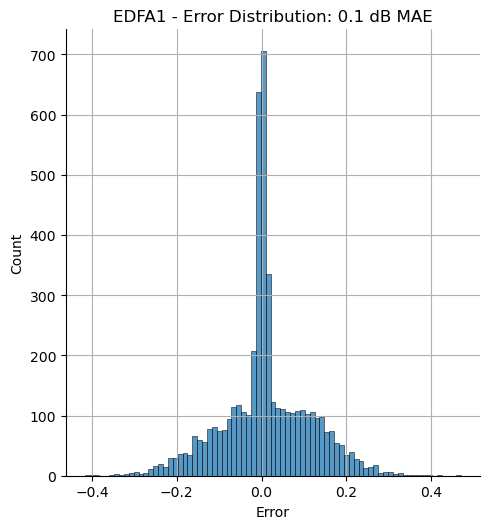

In [ ]:
# import seaborn as sb
# import matplotlib.pyplot as plt

# allErrors = (preds - y_test.cpu().numpy()[:len(preds)]).flatten()
# sb.displot(allErrors)
# plt.xlabel("Error")
# plt.title("EDFA1 - Error Distribution: 0.1 dB MAE")
# plt.grid()